In [ ]:
# # This Python 3 environment comes with many helpful analytics libraries installed
# # It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# # For example, here's several helpful packages to load

# import numpy as np # linear algebra
# import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# # Input data files are available in the read-only "../input/" directory
# # For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

# import os
# for dirname, _, filenames in os.walk('/kaggle/input'):
#     for filename in filenames:
#         print(os.path.join(dirname, filename))

# # You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# # You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

In [ ]:
# !pip install wfdb neurokit2 numpy scipy scikit-learn xgboost torch tqdm

In [ ]:
# import os
# import numpy as np
# import wfdb

# DATASET_ROOT = "/kaggle/input/final-normal-sinus-dataset/normal-sinus-rhythm-rr-interval-database-1.0.0"

# def list_records(dataset_root):
#     rec_path = os.path.join(dataset_root, "RECORDS")
#     if os.path.exists(rec_path):
#         with open(rec_path, "r") as f:
#             return [ln.strip() for ln in f if ln.strip()]
#     return sorted({fn[:-4] for fn in os.listdir(dataset_root) if fn.endswith(".hea")})

# def load_rr_records_from_annotations(dataset_root, ann_ext="ecg", verbose=True):
#     """
#     Reads beat annotations from <record>.<ann_ext> (here ann_ext='ecg')
#     and converts to RR intervals in milliseconds.

#     Returns:
#         rr_records: List[np.ndarray], each 1D float32 RR series in ms
#     """
#     rr_records = []
#     recs = list_records(dataset_root)

#     for rec in recs:
#         try:
#             # header contains fs=128 (samples/sec)
#             hdr = wfdb.rdheader(os.path.join(dataset_root, rec))
#             fs = float(hdr.fs)

#             # read annotations from nsrXXX.ecg
#             ann = wfdb.rdann(os.path.join(dataset_root, rec), extension=ann_ext)

#             # ann.sample are beat locations in samples
#             samples = np.asarray(ann.sample, dtype=np.int64)

#             if samples.size < 2:
#                 if verbose:
#                     print(f"Skip {rec}: <2 beat samples")
#                 continue

#             # RR in seconds = diff(samples)/fs
#             rr_sec = np.diff(samples) / fs

#             # convert to milliseconds
#             rr_ms = (rr_sec * 1000.0).astype(np.float32)

#             # basic cleaning (optional but recommended)
#             rr_ms = rr_ms[np.isfinite(rr_ms)]
#             rr_ms = rr_ms[(rr_ms > 200) & (rr_ms < 3000)]  # keep plausible RR in ms

#             if rr_ms.size < 10:
#                 if verbose:
#                     print(f"Skip {rec}: too few RR after cleaning ({rr_ms.size})")
#                 continue

#             rr_records.append(rr_ms)

#         except Exception as e:
#             if verbose:
#                 print(f"Skip {rec}: {e}")

#     if verbose:
#         print(f"\nLoaded {len(rr_records)} RR records (from annotations).")
#         if len(rr_records) > 0:
#             lens = np.array([len(r) for r in rr_records])
#             print(f"RR length (#intervals): min={lens.min()} mean={lens.mean():.1f} max={lens.max()}")

#     return rr_records

# def detect_rr_unit(rr_records):
#     """
#     After loading with the function above, RR is already in ms.
#     This check is still useful to confirm scale.
#     """
#     all_rr = np.concatenate(rr_records).astype(np.float64)
#     p1, p50, p99 = np.percentile(all_rr, [1, 50, 99])
#     print("\nRR scale check (should be ms):")
#     print(f"  1% / 50% / 99%: {p1:.2f} / {p50:.2f} / {p99:.2f}")
#     print("  example (first 10):", rr_records[0][:10])

#     hr = 60000.0 / all_rr
#     hr = hr[(hr > 0) & (hr < 400)]
#     print(f"Heart-rate sanity (BPM): min={hr.min():.1f} mean={hr.mean():.1f} max={hr.max():.1f}")

# # ---- RUN ----
# rr_records = load_rr_records_from_annotations(DATASET_ROOT, ann_ext="ecg", verbose=True)
# detect_rr_unit(rr_records)


**That means all the record are in miliseconds**

In [ ]:
# import os
# import numpy as np
# import wfdb

# DATASET_ROOT = "/kaggle/input/final-normal-sinus-dataset/normal-sinus-rhythm-rr-interval-database-1.0.0"

# def list_records(dataset_root):
#     rec_path = os.path.join(dataset_root, "RECORDS")
#     if os.path.exists(rec_path):
#         with open(rec_path, "r") as f:
#             return [ln.strip() for ln in f if ln.strip()]
#     return sorted({fn[:-4] for fn in os.listdir(dataset_root) if fn.endswith(".hea")})

# def load_rr_records_patientwise(dataset_root, ann_ext="ecg"):
#     """
#     Returns:
#         rr_dict: dict {record_name: rr_array_in_ms}
#     """
#     rr_dict = {}
#     recs = list_records(dataset_root)

#     for rec in recs:
#         try:
#             hdr = wfdb.rdheader(os.path.join(dataset_root, rec))
#             fs = float(hdr.fs)

#             ann = wfdb.rdann(os.path.join(dataset_root, rec), extension=ann_ext)
#             samples = np.asarray(ann.sample, dtype=np.int64)

#             if len(samples) < 2:
#                 continue

#             rr_ms = np.diff(samples) / fs * 1000.0
#             rr_ms = rr_ms.astype(np.float32)

#             # basic physiological cleaning
#             rr_ms = rr_ms[np.isfinite(rr_ms)]
#             rr_ms = rr_ms[(rr_ms > 200) & (rr_ms < 3000)]

#             if len(rr_ms) > 0:
#                 rr_dict[rec] = rr_ms

#         except Exception as e:
#             print(f"Skip {rec}: {e}")

#     print(f"Loaded RR intervals for {len(rr_dict)} patients.")
#     return rr_dict

# # --------------------------------------------------
# # LOAD RR INTERVALS (patient-wise)
# # --------------------------------------------------
# rr_patient_dict = load_rr_records_patientwise(DATASET_ROOT)

# # --------------------------------------------------
# # PRINT RR INTERVALS PATIENT-WISE
# # --------------------------------------------------
# MAX_PRINT = 20   # change to None to print ALL (not recommended)

# for patient_id, rr in rr_patient_dict.items():
#     print("\n================================================")
#     print(f"Patient: {patient_id}")
#     print(f"Total RR intervals: {len(rr)}")

#     if MAX_PRINT is None:
#         print("RR intervals (ms):")
#         print(rr.tolist())
#     else:
#         print(f"First {MAX_PRINT} RR intervals (ms):")
#         print(rr[:MAX_PRINT].tolist())

#     print("================================================")


**5 mintues segments**

In [ ]:
# import numpy as np

# SEG_MINUTES = 5
# SEG_MS = SEG_MINUTES * 60 * 1000  # 300,000 ms

# def segment_rr_by_time(rr_ms, seg_ms=300_000, min_beats=200, max_beats=800):
#     """
#     rr_ms: 1D array of RR intervals in ms
#     Returns: list of segments, each segment is a 1D array of RR values (variable length)
#     - min_beats/max_beats are safety filters (optional)
#     """
#     segments = []
#     start = 0
#     acc = 0.0

#     for i, v in enumerate(rr_ms):
#         acc += float(v)
#         if acc >= seg_ms:
#             seg = rr_ms[start:i+1]
#             if len(seg) >= min_beats and len(seg) <= max_beats:
#                 segments.append(seg)
#             start = i + 1
#             acc = 0.0

#     return segments

# # Example: make 5-min segments for all patients
# segments_by_patient = {}
# for pid, rr in rr_patient_dict.items():  # rr_patient_dict from your earlier code
#     segments = segment_rr_by_time(rr, seg_ms=SEG_MS)
#     segments_by_patient[pid] = segments
#     print(pid, "=>", len(segments), "segments (5 min each)")


In [ ]:
# # ============================================================
# # RR Interval Imputation (5-minute segments) with:
# #   - LSTM Generator (residual over baseline fill)
# #   - WGAN-GP Critic (1D CNN)
# #   - Missing-only L1 loss
# #   - Physiology loss on dRR
# #
# # Dataset: Normal Sinus Rhythm RR Interval DB (nsr2db)
# # We load beat annotations from .ecg and compute RR in ms using fs=128.
# # Then split into non-overlapping 5-minute segments (300,000 ms).
# # ============================================================

# import os, random
# import numpy as np
# import torch
# import torch.nn as nn
# import torch.optim as optim
# from torch.utils.data import Dataset, DataLoader
# import matplotlib.pyplot as plt
# import wfdb

# # -------------------------
# # CONFIG
# # -------------------------
# DATASET_ROOT = "/kaggle/input/final-normal-sinus-dataset/normal-sinus-rhythm-rr-interval-database-1.0.0"

# SEG_MINUTES = 5
# SEG_MS      = SEG_MINUTES * 60 * 1000  # 300,000 ms

# # fixed length per segment (beats) for GAN/LSTM input
# # 5 minutes at 80 bpm ~ 400 beats; at 60 bpm ~ 300 beats.
# TARGET_LEN  = 400

# K_MISSING    = 5
# BATCH_SIZE   = 128
# EPOCHS       = 100
# N_CRITIC     = 3
# LR_G         = 2e-4
# LR_D         = 2e-4

# LAMBDA_MISS  = 200.0
# LAMBDA_DRR   = 5.0
# LAMBDA_SMOOTH= 0.02
# GP_LAMBDA    = 10.0
# FILL_MODE    = "mean"  # "mean" or "ffill"
# SEED         = 42

# # -------------------------
# # Reproducibility
# # -------------------------
# def seed_all(seed=42):
#     random.seed(seed)
#     np.random.seed(seed)
#     torch.manual_seed(seed)
#     torch.cuda.manual_seed_all(seed)

# seed_all(SEED)
# device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
# print("Device:", device)

# # ============================================================
# # 1) LOAD RR (ms) PATIENT-WISE FROM ANNOTATIONS (.ecg)
# # ============================================================
# def list_records(dataset_root):
#     rec_path = os.path.join(dataset_root, "RECORDS")
#     if os.path.exists(rec_path):
#         with open(rec_path, "r") as f:
#             return [ln.strip() for ln in f if ln.strip()]
#     return sorted({fn[:-4] for fn in os.listdir(dataset_root) if fn.endswith(".hea")})

# def load_rr_patient_dict(dataset_root, ann_ext="ecg", rr_min=200, rr_max=3000, verbose=True):
#     """
#     Returns dict: { "nsr001": rr_ms_array, ... }
#     rr_ms computed from beat samples using fs from header.
#     """
#     rr_dict = {}
#     for rec in list_records(dataset_root):
#         try:
#             hdr = wfdb.rdheader(os.path.join(dataset_root, rec))
#             fs = float(hdr.fs)  # 128 Hz
#             ann = wfdb.rdann(os.path.join(dataset_root, rec), extension=ann_ext)

#             samples = np.asarray(ann.sample, dtype=np.int64)
#             if samples.size < 2:
#                 continue

#             rr_ms = (np.diff(samples) / fs) * 1000.0
#             rr_ms = rr_ms.astype(np.float32)

#             # clean
#             rr_ms = rr_ms[np.isfinite(rr_ms)]
#             rr_ms = rr_ms[(rr_ms > rr_min) & (rr_ms < rr_max)]

#             if rr_ms.size > 0:
#                 rr_dict[rec] = rr_ms
#         except Exception as e:
#             if verbose:
#                 print(f"Skip {rec}: {e}")

#     if verbose:
#         print(f"Loaded RR intervals for {len(rr_dict)} patients.")
#         if len(rr_dict) > 0:
#             lens = np.array([len(v) for v in rr_dict.values()])
#             print(f"RR length (#intervals): min={lens.min()} mean={lens.mean():.1f} max={lens.max()}")

#     return rr_dict

# # ============================================================
# # 2) SEGMENT INTO 5-MIN WINDOWS (VARIABLE BEATS)
# # ============================================================
# def segment_rr_by_time(rr_ms, seg_ms=300_000):
#     """
#     Split RR sequence into non-overlapping time segments of length ~seg_ms.
#     Returns list of np arrays (variable length).
#     """
#     segments = []
#     start = 0
#     acc = 0.0
#     for i, v in enumerate(rr_ms):
#         acc += float(v)
#         if acc >= seg_ms:
#             segments.append(rr_ms[start:i+1])
#             start = i + 1
#             acc = 0.0
#     return segments

# def pad_or_crop(seg, target_len=400, pad_mode="last"):
#     """
#     Convert variable-length segment to fixed length.
#     pad_mode: "last" or "mean"
#     """
#     seg = np.asarray(seg, dtype=np.float32)
#     if len(seg) >= target_len:
#         return seg[:target_len]

#     if pad_mode == "last":
#         pad_val = float(seg[-1])
#     else:
#         pad_val = float(seg.mean())

#     pad = np.full((target_len - len(seg),), pad_val, dtype=np.float32)
#     return np.concatenate([seg, pad], axis=0)

# def build_fixed_segments(rr_patient_dict, seg_ms=300_000, target_len=400,
#                          min_beats=200, max_beats=800, verbose=True):
#     """
#     Returns:
#       segments_all: List[np.ndarray] each shape (target_len,)
#     """
#     segments_all = []
#     per_patient_counts = {}

#     for pid, rr in rr_patient_dict.items():
#         segs = segment_rr_by_time(rr, seg_ms=seg_ms)

#         # optional filter by beats count
#         segs = [s for s in segs if (len(s) >= min_beats and len(s) <= max_beats)]
#         fixed = [pad_or_crop(s, target_len=target_len, pad_mode="last") for s in segs]

#         segments_all.extend(fixed)
#         per_patient_counts[pid] = len(fixed)

#     if verbose:
#         print("\n5-minute segments (fixed length) summary:")
#         for pid in sorted(per_patient_counts.keys()):
#             print(f"{pid} => {per_patient_counts[pid]} segments (5 min each)")
#         print("Total segments:", len(segments_all))
#         print("Each segment shape:", (target_len,))

#     return segments_all, per_patient_counts

# # ---- Load + segment
# rr_patient_dict = load_rr_patient_dict(DATASET_ROOT, ann_ext="ecg", verbose=True)
# segments_all, per_patient_counts = build_fixed_segments(
#     rr_patient_dict, seg_ms=SEG_MS, target_len=TARGET_LEN,
#     min_beats=200, max_beats=800, verbose=True
# )

# # ============================================================
# # 3) DATASET (now each item is a 5-min segment of fixed beats)
# # ============================================================
# class RRSegmentDataset(Dataset):
#     def __init__(self, segments_list):
#         self.samples = [np.asarray(s, dtype=np.float32) for s in segments_list]
#         if len(self.samples) == 0:
#             raise ValueError("No segments available. Check segmentation parameters.")

#     def __len__(self):
#         return len(self.samples)

#     def __getitem__(self, idx):
#         return torch.tensor(self.samples[idx], dtype=torch.float32)

# # ============================================================
# # 4) MASKING / FEATURES
# # ============================================================
# def make_mask_and_corrupt(x, K=5, fill_mode="mean"):
#     B, T = x.shape
#     m = torch.ones((B, T), device=x.device)
#     idx_missing_list = []

#     for b in range(B):
#         idx = torch.randperm(T, device=x.device)[:K]
#         m[b, idx] = 0.0
#         idx_missing_list.append(idx)

#     if fill_mode == "mean":
#         obs_sum = (x * m).sum(dim=1, keepdim=True)
#         obs_cnt = m.sum(dim=1, keepdim=True).clamp(min=1.0)
#         fill = obs_sum / obs_cnt
#         x_obs = x * m + fill * (1.0 - m)

#     elif fill_mode == "ffill":
#         x_obs = x.clone()
#         for b in range(B):
#             missing = (m[b] == 0)
#             obs_idx = torch.where(m[b] == 1)[0]
#             if len(obs_idx) == 0:
#                 continue
#             prev = x_obs[b, obs_idx[0]].item()
#             for t in range(T):
#                 if missing[t]:
#                     x_obs[b, t] = prev
#                 else:
#                     prev = x_obs[b, t].item()
#     else:
#         raise ValueError("fill_mode must be 'mean' or 'ffill'")

#     return x_obs, m, idx_missing_list

# def drr(x):
#     dx = x[:, 1:] - x[:, :-1]
#     dx = torch.cat([torch.zeros((x.size(0), 1), device=x.device), dx], dim=1)
#     return dx

# # ============================================================
# # 5) MODELS
# # ============================================================
# class LSTMGeneratorResidual(nn.Module):
#     def __init__(self, hidden=64, num_layers=2, dropout=0.1):
#         super().__init__()
#         self.lstm = nn.LSTM(
#             input_size=4,
#             hidden_size=hidden,
#             num_layers=num_layers,
#             dropout=dropout if num_layers > 1 else 0.0,
#             batch_first=True,
#             bidirectional=True
#         )
#         self.head = nn.Sequential(
#             nn.Linear(hidden * 2, hidden),
#             nn.ReLU(),
#             nn.Linear(hidden, 1)
#         )

#     def forward(self, x_base, m, noise):
#         dx = drr(x_base)
#         inp = torch.stack([x_base, m, dx, noise], dim=-1)  # (B,T,4)
#         h, _ = self.lstm(inp)
#         delta = self.head(h).squeeze(-1)
#         return delta

# class CNNWganCritic(nn.Module):
#     def __init__(self, channels=64, kernel=5):
#         super().__init__()
#         self.net = nn.Sequential(
#             nn.Conv1d(1, channels, kernel, padding=kernel//2),
#             nn.LeakyReLU(0.2),
#             nn.Conv1d(channels, channels, kernel, padding=kernel//2),
#             nn.LeakyReLU(0.2),
#             nn.Conv1d(channels, channels, kernel, padding=kernel//2),
#             nn.LeakyReLU(0.2),
#         )
#         self.pool = nn.AdaptiveAvgPool1d(1)
#         self.fc = nn.Linear(channels, 1)

#     def forward(self, x):
#         x = x.unsqueeze(1)
#         h = self.net(x)
#         h = self.pool(h).squeeze(-1)
#         return self.fc(h).squeeze(-1)

# # ============================================================
# # 6) WGAN-GP gradient penalty
# # ============================================================
# def gradient_penalty(critic, real, fake, gp_lambda=10.0):
#     B = real.size(0)
#     eps = torch.rand(B, 1, device=real.device).expand_as(real)
#     x_hat = eps * real + (1 - eps) * fake
#     x_hat.requires_grad_(True)

#     scores = critic(x_hat)
#     grads = torch.autograd.grad(
#         outputs=scores,
#         inputs=x_hat,
#         grad_outputs=torch.ones_like(scores),
#         create_graph=True,
#         retain_graph=True,
#         only_inputs=True
#     )[0]

#     grads = grads.view(B, -1)
#     gp = ((grads.norm(2, dim=1) - 1.0) ** 2).mean() * gp_lambda
#     return gp

# # ============================================================
# # 7) TRAIN (on 5-minute fixed segments)
# # ============================================================
# def train_wgan(segments_list):
#     ds = RRSegmentDataset(segments_list)
#     dl = DataLoader(ds, batch_size=BATCH_SIZE, shuffle=True, drop_last=True)
#     print("Total 5-min segments:", len(ds))

#     G = LSTMGeneratorResidual(hidden=64, num_layers=2, dropout=0.1).to(device)
#     D = CNNWganCritic(channels=64, kernel=5).to(device)

#     opt_g = optim.Adam(G.parameters(), lr=LR_G, betas=(0.5, 0.9))
#     opt_d = optim.Adam(D.parameters(), lr=LR_D, betas=(0.5, 0.9))

#     all_vals = np.concatenate([np.asarray(s, dtype=np.float32) for s in segments_list])
#     lo, hi = np.percentile(all_vals, [0.5, 99.5]).astype(np.float32)
#     lo, hi = float(lo), float(hi)
#     print(f"RR clamp range (0.5%..99.5%): [{lo:.2f}, {hi:.2f}]")

#     for ep in range(1, EPOCHS + 1):
#         G.train(); D.train()
#         d_sum = g_sum = miss_sum = drr_sum = 0.0

#         for x in dl:
#             x = x.to(device)  # (B, TARGET_LEN)

#             # ---- Critic updates ----
#             for _ in range(N_CRITIC):
#                 with torch.no_grad():
#                     x_base, m, _ = make_mask_and_corrupt(x, K=K_MISSING, fill_mode=FILL_MODE)
#                     noise = torch.rand_like(x) * (1.0 - m)
#                     delta = G(x_base, m, noise)
#                     x_hat = m * x + (1.0 - m) * (x_base + delta)
#                     x_hat = torch.clamp(x_hat, lo, hi)

#                 real_score = D(x)
#                 fake_score = D(x_hat)
#                 gp = gradient_penalty(D, x, x_hat, gp_lambda=GP_LAMBDA)
#                 d_loss = (fake_score.mean() - real_score.mean()) + gp

#                 opt_d.zero_grad(set_to_none=True)
#                 d_loss.backward()
#                 opt_d.step()

#             # ---- Generator update ----
#             x_base, m, _ = make_mask_and_corrupt(x, K=K_MISSING, fill_mode=FILL_MODE)
#             noise = torch.rand_like(x) * (1.0 - m)
#             delta = G(x_base, m, noise)
#             x_hat = m * x + (1.0 - m) * (x_base + delta)
#             x_hat = torch.clamp(x_hat, lo, hi)

#             adv = -D(x_hat).mean()

#             denom = (1.0 - m).sum().clamp(min=1.0)
#             miss_mae = (torch.abs(x_hat - x) * (1.0 - m)).sum() / denom

#             m_pair = m[:, 1:] * m[:, :-1]
#             miss_drr_mask = 1.0 - m_pair
#             drr_hat = x_hat[:, 1:] - x_hat[:, :-1]
#             drr_true = x[:, 1:] - x[:, :-1]
#             denom_drr = miss_drr_mask.sum().clamp(min=1.0)
#             drr_loss = (torch.abs(drr_hat - drr_true) * miss_drr_mask).sum() / denom_drr

#             smooth = torch.mean(torch.abs(drr_hat))

#             g_loss = adv + LAMBDA_MISS * miss_mae + LAMBDA_DRR * drr_loss + LAMBDA_SMOOTH * smooth

#             opt_g.zero_grad(set_to_none=True)
#             g_loss.backward()
#             opt_g.step()

#             d_sum += d_loss.item()
#             g_sum += g_loss.item()
#             miss_sum += miss_mae.item()
#             drr_sum += drr_loss.item()

#         print(
#             f"Epoch {ep:03d} | D={d_sum/len(dl):.4f} | G={g_sum/len(dl):.4f} | "
#             f"MissMAE={miss_sum/len(dl):.4f} | dRRloss={drr_sum/len(dl):.4f}"
#         )

#     return G, D, lo, hi

# # ============================================================
# # 8) INFERENCE + DEBUG PRINTS (on one 5-min segment)
# # ============================================================
# @torch.no_grad()
# def impute_one_window(G, rr_window, lo=None, hi=None, K=5, verbose=True):
#     G.eval()
#     x = torch.tensor(rr_window, dtype=torch.float32, device=device).unsqueeze(0)  # (1,T)
#     x_base, m, idx_list = make_mask_and_corrupt(x, K=K, fill_mode=FILL_MODE)
#     idx_missing = idx_list[0].detach().cpu().numpy()

#     noise = torch.rand_like(x) * (1.0 - m)
#     delta = G(x_base, m, noise)
#     x_hat = m * x + (1.0 - m) * (x_base + delta)

#     if lo is not None and hi is not None:
#         x_hat = torch.clamp(x_hat, lo, hi)

#     x_np = x.squeeze(0).cpu().numpy()
#     x_base_np = x_base.squeeze(0).cpu().numpy()
#     x_hat_np = x_hat.squeeze(0).cpu().numpy()

#     true_missing = x_np[idx_missing]
#     pred_missing = x_hat_np[idx_missing]
#     abs_err = np.abs(pred_missing - true_missing)

#     mae = float(np.mean(abs_err))
#     rmse = float(np.sqrt(np.mean((pred_missing - true_missing) ** 2)))

#     if verbose:
#         order = np.argsort(idx_missing)
#         idx_s  = idx_missing[order]
#         true_s = true_missing[order]
#         pred_s = pred_missing[order]
#         err_s  = abs_err[order]

#         print("\n================ Missing-value Debug ================")
#         print(f"K={K} missing points")
#         print("Deleted indices     :", idx_s.tolist())
#         print("Deleted TRUE values :", np.round(true_s, 4).tolist())
#         print("Predicted values    :", np.round(pred_s, 4).tolist())
#         print("Abs error           :", np.round(err_s, 4).tolist())
#         print(f"Missing-only MAE={mae:.6f} | RMSE={rmse:.6f}")
#         print("=====================================================\n")

#     return x_np, x_base_np, x_hat_np, idx_missing, mae, rmse

# def plot_imputation(x_true, x_base, x_imputed, idx_missing, title="RR Imputation"):
#     plt.figure(figsize=(12,4))
#     plt.plot(x_true, label="True RR")
#     plt.plot(x_base, label="Masked/Filled RR")
#     plt.plot(x_imputed, label="Imputed RR")
#     plt.scatter(idx_missing, x_true[idx_missing], marker="x", s=90, label="Deleted (true)")
#     plt.scatter(idx_missing, x_imputed[idx_missing], marker="o", s=90, label="Predicted (imputed)")
#     plt.scatter(idx_missing, x_base[idx_missing], marker="s", s=60, label="Baseline fill", alpha=0.7)
#     plt.title(title)
#     plt.legend()
#     plt.grid(True, alpha=0.3)
#     plt.show()

# # ============================================================
# # 9) RUN
# # ============================================================
# G, D, lo, hi = train_wgan(segments_all)

# # Test on one 5-min segment
# test_seg = segments_all[0]  # already fixed length TARGET_LEN
# x_true, x_base, x_imputed, idx_missing, mae, rmse = impute_one_window(
#     G, test_seg, lo=lo, hi=hi, K=K_MISSING, verbose=True
# )

# plot_imputation(
#     x_true, x_base, x_imputed, idx_missing,
#     title=f"5-min Segment (fixed {TARGET_LEN} beats) | K={K_MISSING} | MAE={mae:.2f}ms RMSE={rmse:.2f}ms"
# )

# MODEL_PATH = "/kaggle/working/rr_imputer_lstm_wgangp_5min_segments.pt"
# torch.save({
#     "G_state": G.state_dict(),
#     "lo": lo,
#     "hi": hi,
#     "target_len": TARGET_LEN,
#     "k_missing": K_MISSING,
#     "seg_minutes": SEG_MINUTES
# }, MODEL_PATH)
# print("Saved:", MODEL_PATH)


In [ ]:
# # ============================================================
# # FULL KAGGLE NOTEBOOK (ALL-IN-ONE)
# # 5-minute RR Segment Imputation with:
# #   - LSTM Residual Generator
# #   - WGAN-GP Critic (1D CNN)
# #   - Missing-only L1 loss
# #   - dRR physiology loss
# #
# # Improvements to reduce error:
# #   ✅ Use 5-min time segmentation
# #   ✅ Fixed-length segments (pad/crop) for training
# #   ✅ FILL_MODE = "ffill" (better baseline)
# #   ✅ Block + random masking (more realistic + better generalization)
# #   ✅ Deterministic inference (noise=0)
# #   ✅ Quantize predictions to 7.8125ms grid (128 Hz)
# #   ✅ Tuned loss weights (more focus on missing exactness)
# # ============================================================

# import os, random
# import numpy as np
# import torch
# import torch.nn as nn
# import torch.optim as optim
# from torch.utils.data import Dataset, DataLoader
# import matplotlib.pyplot as plt
# import wfdb

# # -------------------------
# # CONFIG
# # -------------------------
# DATASET_ROOT = "/kaggle/input/final-normal-sinus-dataset/normal-sinus-rhythm-rr-interval-database-1.0.0"

# SEG_MINUTES = 5
# SEG_MS      = SEG_MINUTES * 60 * 1000  # 300,000 ms

# TARGET_LEN  = 400      # ~5 min at ~80 BPM (adjust 300-500 if you want)
# K_MISSING   = 5

# BATCH_SIZE  = 128
# EPOCHS      = 50       # train longer for better results
# N_CRITIC    = 5        # more critic steps helps stability

# LR_G        = 1e-4
# LR_D        = 1e-4

# LAMBDA_MISS   = 300.0  # stronger exact missing match
# LAMBDA_DRR    = 2.0    # less smoothing pressure
# LAMBDA_SMOOTH = 0.0    # optional: 0.005 if you see spikes

# GP_LAMBDA   = 10.0
# FILL_MODE   = "ffill"  # better baseline than mean
# SEED        = 42

# # Masking strategy
# BLOCK_PROB  = 0.7      # 70% of time use contiguous dropout
# MAX_BLOCK   = 12       # up to 12 consecutive missing points

# # RR cleaning
# RR_MIN_MS = 200
# RR_MAX_MS = 3000

# # Quantization step due to fs=128Hz
# STEP_MS = 1000.0 / 128.0  # 7.8125 ms

# # -------------------------
# # Reproducibility
# # -------------------------
# def seed_all(seed=42):
#     random.seed(seed)
#     np.random.seed(seed)
#     torch.manual_seed(seed)
#     torch.cuda.manual_seed_all(seed)

# seed_all(SEED)
# device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
# print("Device:", device)

# # ============================================================
# # 1) LOAD RR (ms) PATIENT-WISE FROM ANNOTATIONS (.ecg)
# # ============================================================
# def list_records(dataset_root):
#     rec_path = os.path.join(dataset_root, "RECORDS")
#     if os.path.exists(rec_path):
#         with open(rec_path, "r") as f:
#             return [ln.strip() for ln in f if ln.strip()]
#     return sorted({fn[:-4] for fn in os.listdir(dataset_root) if fn.endswith(".hea")})

# def load_rr_patient_dict(dataset_root, ann_ext="ecg", verbose=True):
#     rr_dict = {}
#     recs = list_records(dataset_root)
#     for rec in recs:
#         try:
#             hdr = wfdb.rdheader(os.path.join(dataset_root, rec))
#             fs = float(hdr.fs)  # 128 Hz
#             ann = wfdb.rdann(os.path.join(dataset_root, rec), extension=ann_ext)

#             samples = np.asarray(ann.sample, dtype=np.int64)
#             if samples.size < 2:
#                 continue

#             rr_ms = (np.diff(samples) / fs) * 1000.0
#             rr_ms = rr_ms.astype(np.float32)

#             rr_ms = rr_ms[np.isfinite(rr_ms)]
#             rr_ms = rr_ms[(rr_ms > RR_MIN_MS) & (rr_ms < RR_MAX_MS)]

#             if rr_ms.size > 0:
#                 rr_dict[rec] = rr_ms

#         except Exception as e:
#             if verbose:
#                 print(f"Skip {rec}: {e}")

#     if verbose:
#         print(f"Loaded RR intervals for {len(rr_dict)} patients.")
#         if len(rr_dict) > 0:
#             lens = np.array([len(v) for v in rr_dict.values()])
#             print(f"RR length (#intervals): min={lens.min()} mean={lens.mean():.1f} max={lens.max()}")

#             all_rr = np.concatenate(list(rr_dict.values())).astype(np.float64)
#             p1, p50, p99 = np.percentile(all_rr, [1, 50, 99])
#             print(f"RR scale check ms: 1%={p1:.2f} 50%={p50:.2f} 99%={p99:.2f}")

#     return rr_dict

# # ============================================================
# # 2) SEGMENT INTO 5-MIN WINDOWS (VARIABLE BEATS) -> FIXED LENGTH
# # ============================================================
# def segment_rr_by_time(rr_ms, seg_ms=300_000):
#     segments = []
#     start = 0
#     acc = 0.0
#     for i, v in enumerate(rr_ms):
#         acc += float(v)
#         if acc >= seg_ms:
#             segments.append(rr_ms[start:i+1])
#             start = i + 1
#             acc = 0.0
#     return segments

# def pad_or_crop(seg, target_len=400, pad_mode="last"):
#     seg = np.asarray(seg, dtype=np.float32)
#     if len(seg) >= target_len:
#         return seg[:target_len]
#     pad_val = float(seg[-1]) if pad_mode == "last" else float(seg.mean())
#     pad = np.full((target_len - len(seg),), pad_val, dtype=np.float32)
#     return np.concatenate([seg, pad], axis=0)

# def build_fixed_segments(rr_patient_dict, seg_ms=300_000, target_len=400,
#                          min_beats=200, max_beats=800, verbose=True):
#     segments_all = []
#     per_patient_counts = {}

#     for pid, rr in rr_patient_dict.items():
#         segs = segment_rr_by_time(rr, seg_ms=seg_ms)
#         segs = [s for s in segs if (len(s) >= min_beats and len(s) <= max_beats)]
#         fixed = [pad_or_crop(s, target_len=target_len, pad_mode="last") for s in segs]

#         segments_all.extend(fixed)
#         per_patient_counts[pid] = len(fixed)

#     if verbose:
#         print("\n5-minute segments (fixed length) summary:")
#         for pid in sorted(per_patient_counts.keys()):
#             print(f"{pid} => {per_patient_counts[pid]} segments (5 min each)")
#         print("Total segments:", len(segments_all))
#         print("Each segment shape:", (target_len,))

#     return segments_all, per_patient_counts

# # ============================================================
# # 3) DATASET
# # ============================================================
# class RRSegmentDataset(Dataset):
#     def __init__(self, segments_list):
#         self.samples = [np.asarray(s, dtype=np.float32) for s in segments_list]
#         if len(self.samples) == 0:
#             raise ValueError("No segments available. Check segmentation parameters.")
#     def __len__(self): return len(self.samples)
#     def __getitem__(self, idx):
#         return torch.tensor(self.samples[idx], dtype=torch.float32)

# # ============================================================
# # 4) MASKING / FEATURES
# # ============================================================
# def make_mask_and_corrupt(x, K=5, fill_mode="ffill", block_prob=0.7, max_block=12):
#     """
#     Mixture of block-missing and random-missing.
#     """
#     B, T = x.shape
#     m = torch.ones((B, T), device=x.device)
#     idx_missing_list = []

#     for b in range(B):
#         if torch.rand(1, device=x.device).item() < block_prob:
#             L = int(torch.randint(2, max_block+1, (1,), device=x.device).item())
#             start = int(torch.randint(0, T-L, (1,), device=x.device).item())
#             idx = torch.arange(start, start+L, device=x.device)
#         else:
#             idx = torch.randperm(T, device=x.device)[:K]

#         m[b, idx] = 0.0
#         idx_missing_list.append(idx)

#     # fill
#     if fill_mode == "mean":
#         obs_sum = (x * m).sum(dim=1, keepdim=True)
#         obs_cnt = m.sum(dim=1, keepdim=True).clamp(min=1.0)
#         fill = obs_sum / obs_cnt
#         x_obs = x * m + fill * (1.0 - m)

#     elif fill_mode == "ffill":
#         x_obs = x.clone()
#         for b in range(B):
#             missing = (m[b] == 0)
#             obs_idx = torch.where(m[b] == 1)[0]
#             if len(obs_idx) == 0:
#                 continue
#             prev = x_obs[b, obs_idx[0]].item()
#             for t in range(T):
#                 if missing[t]:
#                     x_obs[b, t] = prev
#                 else:
#                     prev = x_obs[b, t].item()
#     else:
#         raise ValueError("fill_mode must be 'mean' or 'ffill'")

#     return x_obs, m, idx_missing_list

# def drr(x):
#     dx = x[:, 1:] - x[:, :-1]
#     dx = torch.cat([torch.zeros((x.size(0), 1), device=x.device), dx], dim=1)
#     return dx

# # ============================================================
# # 5) MODELS
# # ============================================================
# class LSTMGeneratorResidual(nn.Module):
#     def __init__(self, hidden=64, num_layers=2, dropout=0.1):
#         super().__init__()
#         self.lstm = nn.LSTM(
#             input_size=4,
#             hidden_size=hidden,
#             num_layers=num_layers,
#             dropout=dropout if num_layers > 1 else 0.0,
#             batch_first=True,
#             bidirectional=True
#         )
#         self.head = nn.Sequential(
#             nn.Linear(hidden * 2, hidden),
#             nn.ReLU(),
#             nn.Linear(hidden, 1)
#         )

#     def forward(self, x_base, m, noise):
#         dx = drr(x_base)
#         inp = torch.stack([x_base, m, dx, noise], dim=-1)  # (B,T,4)
#         h, _ = self.lstm(inp)
#         delta = self.head(h).squeeze(-1)
#         return delta

# class CNNWganCritic(nn.Module):
#     def __init__(self, channels=64, kernel=5):
#         super().__init__()
#         self.net = nn.Sequential(
#             nn.Conv1d(1, channels, kernel, padding=kernel//2),
#             nn.LeakyReLU(0.2),
#             nn.Conv1d(channels, channels, kernel, padding=kernel//2),
#             nn.LeakyReLU(0.2),
#             nn.Conv1d(channels, channels, kernel, padding=kernel//2),
#             nn.LeakyReLU(0.2),
#         )
#         self.pool = nn.AdaptiveAvgPool1d(1)
#         self.fc = nn.Linear(channels, 1)

#     def forward(self, x):
#         x = x.unsqueeze(1)
#         h = self.net(x)
#         h = self.pool(h).squeeze(-1)
#         return self.fc(h).squeeze(-1)

# # ============================================================
# # 6) WGAN-GP GRADIENT PENALTY
# # ============================================================
# def gradient_penalty(critic, real, fake, gp_lambda=10.0):
#     B = real.size(0)
#     eps = torch.rand(B, 1, device=real.device).expand_as(real)
#     x_hat = eps * real + (1 - eps) * fake
#     x_hat.requires_grad_(True)

#     scores = critic(x_hat)
#     grads = torch.autograd.grad(
#         outputs=scores,
#         inputs=x_hat,
#         grad_outputs=torch.ones_like(scores),
#         create_graph=True,
#         retain_graph=True,
#         only_inputs=True
#     )[0]

#     grads = grads.view(B, -1)
#     gp = ((grads.norm(2, dim=1) - 1.0) ** 2).mean() * gp_lambda
#     return gp

# # ============================================================
# # 7) TRAIN
# # ============================================================
# def train_wgan(segments_list):
#     ds = RRSegmentDataset(segments_list)
#     dl = DataLoader(ds, batch_size=BATCH_SIZE, shuffle=True, drop_last=True)
#     print("Total 5-min segments:", len(ds))

#     G = LSTMGeneratorResidual(hidden=64, num_layers=2, dropout=0.1).to(device)
#     D = CNNWganCritic(channels=64, kernel=5).to(device)

#     opt_g = optim.Adam(G.parameters(), lr=LR_G, betas=(0.5, 0.9))
#     opt_d = optim.Adam(D.parameters(), lr=LR_D, betas=(0.5, 0.9))

#     all_vals = np.concatenate([np.asarray(s, dtype=np.float32) for s in segments_list])
#     lo, hi = np.percentile(all_vals, [0.5, 99.5]).astype(np.float32)
#     lo, hi = float(lo), float(hi)
#     print(f"RR clamp range (0.5%..99.5%): [{lo:.2f}, {hi:.2f}]")

#     for ep in range(1, EPOCHS + 1):
#         G.train(); D.train()
#         d_sum = g_sum = miss_sum = drr_sum = 0.0

#         for x in dl:
#             x = x.to(device)  # (B,T)

#             # ---- Critic updates ----
#             for _ in range(N_CRITIC):
#                 with torch.no_grad():
#                     x_base, m, _ = make_mask_and_corrupt(
#                         x, K=K_MISSING, fill_mode=FILL_MODE,
#                         block_prob=BLOCK_PROB, max_block=MAX_BLOCK
#                     )
#                     noise = torch.rand_like(x) * (1.0 - m)
#                     delta = G(x_base, m, noise)
#                     x_hat = m * x + (1.0 - m) * (x_base + delta)

#                     # quantize to 128Hz RR grid
#                     x_hat = torch.round(x_hat / STEP_MS) * STEP_MS
#                     x_hat = torch.clamp(x_hat, lo, hi)

#                 real_score = D(x)
#                 fake_score = D(x_hat)
#                 gp = gradient_penalty(D, x, x_hat, gp_lambda=GP_LAMBDA)
#                 d_loss = (fake_score.mean() - real_score.mean()) + gp

#                 opt_d.zero_grad(set_to_none=True)
#                 d_loss.backward()
#                 opt_d.step()

#             # ---- Generator update ----
#             x_base, m, _ = make_mask_and_corrupt(
#                 x, K=K_MISSING, fill_mode=FILL_MODE,
#                 block_prob=BLOCK_PROB, max_block=MAX_BLOCK
#             )
#             noise = torch.rand_like(x) * (1.0 - m)
#             delta = G(x_base, m, noise)
#             x_hat = m * x + (1.0 - m) * (x_base + delta)

#             # quantize to 128Hz RR grid
#             x_hat = torch.round(x_hat / STEP_MS) * STEP_MS
#             x_hat = torch.clamp(x_hat, lo, hi)

#             adv = -D(x_hat).mean()

#             denom = (1.0 - m).sum().clamp(min=1.0)
#             miss_mae = (torch.abs(x_hat - x) * (1.0 - m)).sum() / denom

#             m_pair = m[:, 1:] * m[:, :-1]
#             miss_drr_mask = 1.0 - m_pair
#             drr_hat = x_hat[:, 1:] - x_hat[:, :-1]
#             drr_true = x[:, 1:] - x[:, :-1]
#             denom_drr = miss_drr_mask.sum().clamp(min=1.0)
#             drr_loss = (torch.abs(drr_hat - drr_true) * miss_drr_mask).sum() / denom_drr

#             smooth = torch.mean(torch.abs(drr_hat))

#             g_loss = adv + LAMBDA_MISS * miss_mae + LAMBDA_DRR * drr_loss + LAMBDA_SMOOTH * smooth

#             opt_g.zero_grad(set_to_none=True)
#             g_loss.backward()
#             opt_g.step()

#             d_sum += d_loss.item()
#             g_sum += g_loss.item()
#             miss_sum += miss_mae.item()
#             drr_sum += drr_loss.item()

#         print(
#             f"Epoch {ep:03d} | D={d_sum/len(dl):.4f} | G={g_sum/len(dl):.4f} | "
#             f"MissMAE={miss_sum/len(dl):.4f} | dRRloss={drr_sum/len(dl):.4f}"
#         )

#     return G, D, lo, hi

# # ============================================================
# # 8) INFERENCE + DEBUG (deterministic + quantized)
# # ============================================================
# @torch.no_grad()
# def impute_one_segment(G, rr_segment, lo=None, hi=None, K=5, verbose=True):
#     G.eval()
#     x = torch.tensor(rr_segment, dtype=torch.float32, device=device).unsqueeze(0)
#     x_base, m, idx_list = make_mask_and_corrupt(
#         x, K=K, fill_mode=FILL_MODE, block_prob=0.0, max_block=MAX_BLOCK
#     )
#     idx_missing = idx_list[0].detach().cpu().numpy()

#     # deterministic inference
#     noise = torch.zeros_like(x)

#     delta = G(x_base, m, noise)
#     x_hat = m * x + (1.0 - m) * (x_base + delta)

#     # quantize to grid
#     x_hat = torch.round(x_hat / STEP_MS) * STEP_MS

#     if lo is not None and hi is not None:
#         x_hat = torch.clamp(x_hat, lo, hi)

#     x_np = x.squeeze(0).cpu().numpy()
#     x_base_np = x_base.squeeze(0).cpu().numpy()
#     x_hat_np = x_hat.squeeze(0).cpu().numpy()

#     true_missing = x_np[idx_missing]
#     pred_missing = x_hat_np[idx_missing]
#     abs_err = np.abs(pred_missing - true_missing)

#     mae = float(np.mean(abs_err))
#     rmse = float(np.sqrt(np.mean((pred_missing - true_missing) ** 2)))

#     # baselines for comparison
#     base_missing = x_base_np[idx_missing]
#     base_mae = float(np.mean(np.abs(base_missing - true_missing)))

#     if verbose:
#         order = np.argsort(idx_missing)
#         rel_err = (abs_err / (true_missing + 1e-6)) * 100.0

#         print("\n================ Missing-value Debug ================")
#         print(f"K={K} missing points")
#         print("Deleted indices     :", idx_missing[order].tolist())
#         print("Deleted TRUE values :", np.round(true_missing[order], 4).tolist())
#         print("Predicted values    :", np.round(pred_missing[order], 4).tolist())
#         print("Abs error (ms)      :", np.round(abs_err[order], 4).tolist())
#         print("Rel error (%)       :", np.round(rel_err[order], 3).tolist())
#         print(f"Missing-only MAE={mae:.6f} ms ({mae/1000:.6f} s) | RMSE={rmse:.6f} ms")
#         print(f"Baseline-fill MAE={base_mae:.6f} ms")
#         print("=====================================================\n")

#     return x_np, x_base_np, x_hat_np, idx_missing, mae, rmse, base_mae

# def plot_imputation(x_true, x_base, x_imputed, idx_missing, title="RR Imputation"):
#     plt.figure(figsize=(12,4))
#     plt.plot(x_true, label="True RR")
#     plt.plot(x_base, label="Masked/Filled RR")
#     plt.plot(x_imputed, label="Imputed RR")
#     plt.scatter(idx_missing, x_true[idx_missing], marker="x", s=90, label="Deleted (true)")
#     plt.scatter(idx_missing, x_imputed[idx_missing], marker="o", s=90, label="Predicted (imputed)")
#     plt.scatter(idx_missing, x_base[idx_missing], marker="s", s=60, label="Baseline fill", alpha=0.7)
#     plt.title(title)
#     plt.legend()
#     plt.grid(True, alpha=0.3)
#     plt.show()

# # ============================================================
# # 9) RUN
# # ============================================================
# rr_patient_dict = load_rr_patient_dict(DATASET_ROOT, ann_ext="ecg", verbose=True)
# segments_all, per_patient_counts = build_fixed_segments(
#     rr_patient_dict, seg_ms=SEG_MS, target_len=TARGET_LEN,
#     min_beats=200, max_beats=800, verbose=True
# )

# G, D, lo, hi = train_wgan(segments_all)

# # Test on one segment (deterministic inference)
# test_seg = segments_all[0]
# x_true, x_base, x_imp, idx_miss, mae, rmse, base_mae = impute_one_segment(
#     G, test_seg, lo=lo, hi=hi, K=K_MISSING, verbose=True
# )

# plot_imputation(
#     x_true, x_base, x_imp, idx_miss,
#     title=f"5-min Segment (fixed {TARGET_LEN} beats) | K={K_MISSING} | MAE={mae:.2f}ms RMSE={rmse:.2f}ms | baseMAE={base_mae:.2f}ms"
# )

# MODEL_PATH = "/kaggle/working/rr_imputer_lstm_wgangp_5min_segments_best.pt"
# torch.save({
#     "G_state": G.state_dict(),
#     "lo": lo,
#     "hi": hi,
#     "target_len": TARGET_LEN,
#     "k_missing": K_MISSING,
#     "seg_minutes": SEG_MINUTES,
#     "step_ms": STEP_MS,
#     "fill_mode": FILL_MODE
# }, MODEL_PATH)
# print("Saved:", MODEL_PATH)


In [ ]:
# !pip -q install -U "pandas==2.2.3" "wfdb==4.3.0"

In [1]:
# 1. Install a compatible version of pandas and update wfdb
!pip install "pandas<2.2.0" wfdb -U

# 2. IMPORTANT: You must restart the kernel after installing!
# In Kaggle: Run this cell -> Click "Run" in menu -> "Restart Session"

  Using cached wfdb-4.3.0-py3-none-any.whl.metadata (3.8 kB)
INFO: pip is looking at multiple versions of wfdb to determine which version is compatible with other requirements. This could take a while.
  Using cached wfdb-4.2.0-py3-none-any.whl.metadata (3.7 kB)


Device: cuda
Found 54 records.

Loaded 54 RR records (from annotations).
RR length (#intervals): min=76849 mean=107358.1 max=136536

RR scale check (should be seconds):
  1% / 50% / 99%: 0.4531 / 0.7578 / 1.2031
  example (first 10): [0.6953125, 0.7109375, 0.7109375, 0.703125, 0.7109375, 0.6796875, 0.6953125, 0.6640625, 0.6875, 0.65625]

Heart-rate sanity (BPM): min=20.1 mean=81.1 max=295.4

Built 8456 fixed-length samples from 5-min segments.
Example per-patient segment counts (original variable-length):
  nsr001 => 448 segments (5 min each)
  nsr002 => 465 segments (5 min each)
  nsr003 => 468 segments (5 min each)
  nsr004 => 461 segments (5 min each)
  nsr005 => 475 segments (5 min each)
  ...

Patient-wise split:
  Train patients: 43 | Train samples: 6633
  Test  patients: 11  | Test samples : 1823
Train samples: 6633
RR clamp range (0.5%..99.5%): [0.4062, 0.8516] s


/usr/local/lib/python3.12/dist-packages/torch/autograd/graph.py:829: UserWarning: Attempting to run cuBLAS, but there was no current CUDA context! Attempting to set the primary context... (Triggered internally at /pytorch/aten/src/ATen/cuda/CublasHandlePool.cpp:179.)
  return Variable._execution_engine.run_backward(  # Calls into the C++ engine to run the backward pass


Epoch 001 | D=4.1871 | G=227.7642 | MissMAE(z)=0.4539 | dRRloss(z)=0.4110
Epoch 002 | D=-0.0705 | G=207.3542 | MissMAE(z)=0.4131 | dRRloss(z)=0.3897
Epoch 003 | D=-0.1842 | G=201.2940 | MissMAE(z)=0.4011 | dRRloss(z)=0.3808
Epoch 004 | D=-0.3147 | G=194.5051 | MissMAE(z)=0.3875 | dRRloss(z)=0.3698
Epoch 005 | D=-0.4330 | G=192.5132 | MissMAE(z)=0.3836 | dRRloss(z)=0.3674
Epoch 006 | D=-0.4861 | G=178.0937 | MissMAE(z)=0.3847 | dRRloss(z)=0.3710
Epoch 007 | D=-0.4866 | G=173.2328 | MissMAE(z)=0.3730 | dRRloss(z)=0.3623
Epoch 008 | D=-0.5135 | G=172.7730 | MissMAE(z)=0.3682 | dRRloss(z)=0.3581
Epoch 009 | D=-0.5251 | G=170.9089 | MissMAE(z)=0.3612 | dRRloss(z)=0.3541
Epoch 010 | D=-0.5273 | G=170.0129 | MissMAE(z)=0.3593 | dRRloss(z)=0.3497
Epoch 011 | D=-0.5359 | G=168.0125 | MissMAE(z)=0.3559 | dRRloss(z)=0.3502
Epoch 012 | D=-0.5336 | G=167.4116 | MissMAE(z)=0.3553 | dRRloss(z)=0.3472
Epoch 013 | D=-0.5361 | G=165.1894 | MissMAE(z)=0.3518 | dRRloss(z)=0.3451
Epoch 014 | D=-0.5377 | G=

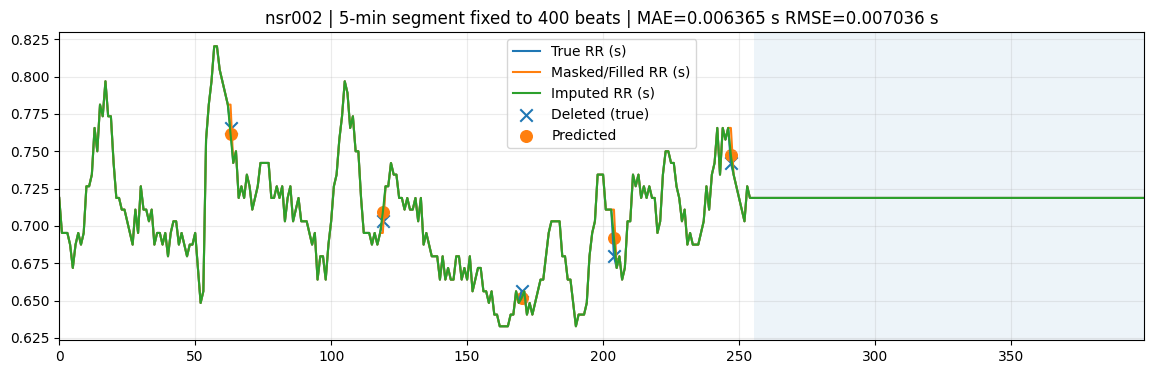

Saved: /kaggle/working/rr_imputer_5min_wgangp_lstm_residual_seconds.pt


In [2]:
# ============================================================
# KAGGLE FULL NOTEBOOK (ALL-IN-ONE) ✅
# RR Interval Imputation on NSRDB RR-Interval DB (nsr2db)
#
# ✅ Loads RR intervals from WFDB annotation files (*.ecg as ann)
# ✅ RR is in SECONDS (s)  ✅ (CHANGED FROM ms)
# ✅ Builds TRUE 5-minute segments (300 seconds each)
# ✅ Converts variable-length 5-min segments -> fixed length (TARGET_LEN beats)
# ✅ Trains LSTM Generator (residual) + WGAN-GP Critic (CNN)
# ✅ Missing-only MAE + physiology dRR loss + optional smoothness
# ✅ Warmup epochs (reconstruction first) to reduce MAE
# ✅ Missing pattern: 50% contiguous block, 50% scattered
# ✅ Debug prints: missing indices, true, pred, abs error
# ✅ Plot: true / baseline fill / imputed, mark missing points
# ============================================================

import os, random
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import matplotlib.pyplot as plt
import wfdb

# -------------------------
# CONFIG  (SECONDS)
# -------------------------
DATASET_ROOT = "/kaggle/input/nsrrrid/normal-sinus-rhythm-rr-interval-database-1.0.0"

SEG_S        = 180.0            # 5 minutes = 300 seconds ✅
TARGET_LEN   = 400              # fixed beats per segment (≈ 5min at ~80 bpm)
MIN_LEN_KEEP = 250              # discard too-short 5-min segments (<250 beats)

K_MISSING    = 5                # missing points per sample
FILL_MODE    = "ffill"          # "mean" or "ffill"

BATCH_SIZE   = 32
EPOCHS       = 30
WARMUP_EPOCHS= 5                # recon-only warmup
N_CRITIC     = 1

LR_G         = 1e-4
LR_D         = 1e-4

LAMBDA_MISS  = 500.0            # stronger missing-only match
LAMBDA_DRR   = 2.0              # physiology
LAMBDA_SMOOTH= 0.0              # usually off helps MAE

GP_LAMBDA    = 10.0

SEED         = 42

# -------------------------
# Reproducibility
# -------------------------
def seed_all(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

seed_all(SEED)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

# ============================================================
# 1) LOAD RR FROM WFDB ANNOTATIONS (*.ecg as annotation)
#    RR computed in SECONDS: diff(samples)/fs
# ============================================================
def list_records(dataset_root: str):
    rec_path = os.path.join(dataset_root, "RECORDS")
    if os.path.isfile(rec_path):
        with open(rec_path, "r") as f:
            recs = [ln.strip() for ln in f if ln.strip()]
        return recs
    # fallback: infer from *.hea
    recs = sorted([fn.replace(".hea", "") for fn in os.listdir(dataset_root) if fn.endswith(".hea")])
    return recs

def load_rr_records_from_wfdb(dataset_root: str, ann_ext="ecg", verbose=True):
    """
    Reads:
      - header: wfdb.rdheader(record)
      - annotations: wfdb.rdann(record, ann_ext)  (here ann_ext='ecg')
    RR is computed from successive annotation sample indices:
      RR_s = diff(samples) / fs   ✅ seconds
    Returns:
      rr_dict: {record_name: rr_s_array}
      fs_dict: {record_name: fs}
    """
    rr_dict, fs_dict = {}, {}
    recs = list_records(dataset_root)
    if verbose:
        print(f"Found {len(recs)} records.")

    for rec in recs:
        try:
            rec_path = os.path.join(dataset_root, rec)
            header = wfdb.rdheader(rec_path)
            fs = float(header.fs) if header.fs is not None else None
            if fs is None:
                raise RuntimeError("Header fs is None")

            ann = wfdb.rdann(rec_path, ann_ext)
            samples = np.asarray(ann.sample, dtype=np.int64)
            if samples.size < 2:
                raise RuntimeError("Not enough annotations")

            # ✅ RR in seconds
            rr_s = (np.diff(samples) / fs).astype(np.float32)

            # basic cleaning (seconds)
            rr_s = rr_s[np.isfinite(rr_s)]
            rr_s = rr_s[(rr_s > 0.2) & (rr_s < 3.0)]  # 0.2s..3.0s plausible

            if rr_s.size < 1000:
                raise RuntimeError(f"Too few RR after cleaning: {rr_s.size}")

            rr_dict[rec] = rr_s
            fs_dict[rec] = fs
        except Exception as e:
            if verbose:
                print(f"Skip {rec}: {e}")

    if verbose:
        print(f"\nLoaded {len(rr_dict)} RR records (from annotations).")
        if len(rr_dict) > 0:
            lens = [len(v) for v in rr_dict.values()]
            print(f"RR length (#intervals): min={np.min(lens)} mean={np.mean(lens):.1f} max={np.max(lens)}")

            # quick unit sanity
            all_rr = np.concatenate(list(rr_dict.values())).astype(np.float64)
            p1, p50, p99 = np.percentile(all_rr, [1, 50, 99])
            print("\nRR scale check (should be seconds):")
            print(f"  1% / 50% / 99%: {p1:.4f} / {p50:.4f} / {p99:.4f}")
            print("  example (first 10):", list(rr_dict[list(rr_dict.keys())[0]][:10]))

            hr = 60.0 / all_rr
            print("\nHeart-rate sanity (BPM): min={:.1f} mean={:.1f} max={:.1f}".format(
                np.min(hr), np.mean(hr), np.max(hr)
            ))

    return rr_dict, fs_dict

rr_dict, fs_dict = load_rr_records_from_wfdb(DATASET_ROOT, ann_ext="ecg", verbose=True)
assert len(rr_dict) > 0, "❌ rr_dict empty. Check dataset path + annotation extension (try ann_ext='atr' if needed)."

# ============================================================
# 2) BUILD TRUE 5-MINUTE SEGMENTS (time-based, seconds)
# ============================================================
def split_into_time_segments(rr_s: np.ndarray, seg_s=300.0):
    """
    Returns list of segments, each segment is RR (seconds)
    such that cumulative time in each segment reaches seg_s.
    """
    segments = []
    acc = 0.0
    cur = []
    for v in rr_s:
        cur.append(float(v))
        acc += float(v)
        if acc >= seg_s:
            segments.append(np.asarray(cur, dtype=np.float32))
            acc = 0.0
            cur = []
    return segments

def make_fixed_length(seg: np.ndarray, target_len=400, min_keep=250):
    """
    Convert variable-length segment -> fixed length:
    - if seg too short (<min_keep): return None
    - if seg >= target_len: random crop length target_len
    - if seg < target_len: pad using edge value
    Returns:
      x_fixed (target_len,)
      valid_mask (target_len,) 1 for real, 0 for padded
    """
    L = len(seg)
    if L < min_keep:
        return None, None
    if L >= target_len:
        start = np.random.randint(0, L - target_len + 1)
        x = seg[start:start+target_len].copy()
        valid = np.ones((target_len,), dtype=np.float32)
        return x, valid
    else:
        x = np.empty((target_len,), dtype=np.float32)
        valid = np.zeros((target_len,), dtype=np.float32)
        x[:L] = seg
        valid[:L] = 1.0
        x[L:] = seg[-1]  # pad with last real RR
        return x, valid

# Build dataset of fixed-length 5-min segments
segments_by_patient = {}
fixed_samples = []   # list of (patient_id, x_fixed, valid_mask)

for pid, rr in rr_dict.items():
    segs = split_into_time_segments(rr, seg_s=SEG_S)
    segments_by_patient[pid] = segs
    for seg in segs:
        x, valid = make_fixed_length(seg, target_len=TARGET_LEN, min_keep=MIN_LEN_KEEP)
        if x is not None:
            fixed_samples.append((pid, x, valid))

print(f"\nBuilt {len(fixed_samples)} fixed-length samples from 5-min segments.")
print("Example per-patient segment counts (original variable-length):")
for pid in sorted(list(segments_by_patient.keys()))[:5]:
    print(f"  {pid} => {len(segments_by_patient[pid])} segments (5 min each)")
print("  ...")

# ============================================================
# 3) TRAIN/TEST SPLIT (PATIENT-WISE ✅)
# ============================================================
all_pids = sorted(list(rr_dict.keys()))
random.shuffle(all_pids)

n_train = int(0.8 * len(all_pids))
train_pids = set(all_pids[:n_train])
test_pids  = set(all_pids[n_train:])

train_samples = [(pid,x,v) for (pid,x,v) in fixed_samples if pid in train_pids]
test_samples  = [(pid,x,v) for (pid,x,v) in fixed_samples if pid in test_pids]

print(f"\nPatient-wise split:")
print(f"  Train patients: {len(train_pids)} | Train samples: {len(train_samples)}")
print(f"  Test  patients: {len(test_pids)}  | Test samples : {len(test_samples)}")

# ============================================================
# 4) DATASET + MASKING (avoid padded positions)
# ============================================================
class RR5MinDataset(Dataset):
    def __init__(self, samples):
        self.samples = samples

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        pid, x, valid = self.samples[idx]
        return pid, torch.tensor(x, dtype=torch.float32), torch.tensor(valid, dtype=torch.float32)

def make_mask_and_corrupt(x, valid_mask, K=5, fill_mode="ffill"):
    """
    x: (B,T) RR in seconds (or normalized)
    valid_mask: (B,T) 1=real,0=padded
    returns:
      x_obs: baseline-filled (B,T)
      m:     observed mask (B,T): 1 observed, 0 missing
      idx_missing_list: list of missing indices per batch
    """
    B, T = x.shape
    m = torch.ones((B, T), device=x.device)
    idx_missing_list = []

    for b in range(B):
        valid_idx = torch.where(valid_mask[b] > 0.5)[0]
        if valid_idx.numel() <= K:
            idx = valid_idx
        else:
            if torch.rand(1, device=x.device).item() < 0.5:
                # contiguous block inside valid range
                min_i = int(valid_idx.min().item())
                max_i = int(valid_idx.max().item())
                start = torch.randint(min_i, max_i - K + 2, (1,), device=x.device).item()
                idx = torch.arange(start, start + K, device=x.device)
            else:
                # scattered
                perm = valid_idx[torch.randperm(valid_idx.numel(), device=x.device)]
                idx = perm[:K]

        m[b, idx] = 0.0
        idx_missing_list.append(idx)

    # baseline fill
    if fill_mode == "mean":
        obs_sum = (x * m).sum(dim=1, keepdim=True)
        obs_cnt = m.sum(dim=1, keepdim=True).clamp(min=1.0)
        fill = obs_sum / obs_cnt
        x_obs = x * m + fill * (1.0 - m)

    elif fill_mode == "ffill":
        x_obs = x.clone()
        for b in range(B):
            missing = (m[b] == 0)
            valid_idx = torch.where(valid_mask[b] > 0.5)[0]
            if valid_idx.numel() == 0:
                continue
            first = int(valid_idx[0].item())
            prev = x_obs[b, first].item()
            for t in range(T):
                if valid_mask[b, t] < 0.5:
                    continue
                if missing[t]:
                    x_obs[b, t] = prev
                else:
                    prev = x_obs[b, t].item()
    else:
        raise ValueError("fill_mode must be 'mean' or 'ffill'")

    return x_obs, m, idx_missing_list

def drr(x):
    dx = x[:, 1:] - x[:, :-1]
    dx = torch.cat([torch.zeros((x.size(0), 1), device=x.device), dx], dim=1)
    return dx

# ============================================================
# 5) MODELS
# ============================================================
class LSTMGeneratorResidual(nn.Module):
    def __init__(self, hidden=96, num_layers=2, dropout=0.1):
        super().__init__()
        self.lstm = nn.LSTM(
            input_size=4,
            hidden_size=hidden,
            num_layers=num_layers,
            dropout=dropout if num_layers > 1 else 0.0,
            batch_first=True,
            bidirectional=True
        )
        self.head = nn.Sequential(
            nn.Linear(hidden * 2, hidden),
            nn.ReLU(),
            nn.Linear(hidden, 1)
        )

    def forward(self, x_base, m, noise):
        dx = drr(x_base)
        inp = torch.stack([x_base, m, dx, noise], dim=-1)  # (B,T,4)
        h, _ = self.lstm(inp)
        delta = self.head(h).squeeze(-1)
        return delta

class CNNWganCritic(nn.Module):
    def __init__(self, channels=64, kernel=5):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv1d(1, channels, kernel, padding=kernel//2),
            nn.LeakyReLU(0.2),
            nn.Conv1d(channels, channels, kernel, padding=kernel//2),
            nn.LeakyReLU(0.2),
            nn.Conv1d(channels, channels, kernel, padding=kernel//2),
            nn.LeakyReLU(0.2),
        )
        self.pool = nn.AdaptiveAvgPool1d(1)
        self.fc = nn.Linear(channels, 1)

    def forward(self, x):
        x = x.unsqueeze(1)          # (B,1,T)
        h = self.net(x)
        h = self.pool(h).squeeze(-1)
        return self.fc(h).squeeze(-1)

# ============================================================
# 6) WGAN-GP gradient penalty
# ============================================================
def gradient_penalty(critic, real, fake, gp_lambda=10.0):
    B = real.size(0)
    eps = torch.rand(B, 1, device=real.device).expand_as(real)
    x_hat = eps * real + (1 - eps) * fake
    x_hat.requires_grad_(True)

    scores = critic(x_hat)
    grads = torch.autograd.grad(
        outputs=scores,
        inputs=x_hat,
        grad_outputs=torch.ones_like(scores),
        create_graph=True,
        retain_graph=True,
        only_inputs=True
    )[0]

    grads = grads.view(B, -1)
    gp = ((grads.norm(2, dim=1) - 1.0) ** 2).mean() * gp_lambda
    return gp

# ============================================================
# 7) TRAIN (warmup + per-segment normalization)
# ============================================================
def train_wgan(train_samples):
    ds = RR5MinDataset(train_samples)
    dl = DataLoader(ds, batch_size=BATCH_SIZE, shuffle=True, drop_last=True)
    print("Train samples:", len(ds))

    G = LSTMGeneratorResidual(hidden=96, num_layers=2, dropout=0.1).to(device)
    D = CNNWganCritic(channels=64, kernel=5).to(device)

    opt_g = optim.Adam(G.parameters(), lr=LR_G, betas=(0.5, 0.9))
    opt_d = optim.Adam(D.parameters(), lr=LR_D, betas=(0.5, 0.9))

    # compute clamp range on train (seconds)
    all_vals = np.concatenate([x for (_, x, _) in train_samples]).astype(np.float64)
    lo, hi = np.percentile(all_vals, [0.5, 99.5]).astype(np.float32)
    lo, hi = float(lo), float(hi)
    print(f"RR clamp range (0.5%..99.5%): [{lo:.4f}, {hi:.4f}] s")

    for ep in range(1, EPOCHS + 1):
        G.train(); D.train()
        d_sum = g_sum = miss_sum = drr_sum = 0.0

        for _, x_s, valid in dl:
            x_s = x_s.to(device)               # (B,T) in seconds
            valid = valid.to(device)           # (B,T) 1/0

            # per-segment normalization (z-score) over valid region
            mu  = (x_s * valid).sum(dim=1, keepdim=True) / valid.sum(dim=1, keepdim=True).clamp(min=1.0)
            var = (((x_s - mu) ** 2) * valid).sum(dim=1, keepdim=True) / valid.sum(dim=1, keepdim=True).clamp(min=1.0)
            std = torch.sqrt(var).clamp(min=1e-6)
            x = (x_s - mu) / std               # normalized

            # ---- Critic updates ----
            for _ in range(N_CRITIC):
                with torch.no_grad():
                    x_base, m, _ = make_mask_and_corrupt(x, valid, K=K_MISSING, fill_mode=FILL_MODE)
                    noise = torch.rand_like(x) * (1.0 - m)
                    delta = G(x_base, m, noise)
                    x_hat = m * x + (1.0 - m) * (x_base + delta)

                    # clamp in normalized domain
                    x_hat = torch.clamp(x_hat, (lo - mu) / std, (hi - mu) / std)

                real_score = D(x)
                fake_score = D(x_hat)
                gp = gradient_penalty(D, x, x_hat, gp_lambda=GP_LAMBDA)
                d_loss = (fake_score.mean() - real_score.mean()) + gp

                opt_d.zero_grad(set_to_none=True)
                d_loss.backward()
                opt_d.step()

            # ---- Generator update ----
            x_base, m, _ = make_mask_and_corrupt(x, valid, K=K_MISSING, fill_mode=FILL_MODE)
            noise = torch.rand_like(x) * (1.0 - m)
            delta = G(x_base, m, noise)
            x_hat = m * x + (1.0 - m) * (x_base + delta)
            x_hat = torch.clamp(x_hat, (lo - mu) / std, (hi - mu) / std)

            adv = -D(x_hat).mean()
            if ep <= WARMUP_EPOCHS:
                adv = 0.0 * adv

            # missing-only MAE on valid region
            miss_mask = (1.0 - m) * valid
            denom = miss_mask.sum().clamp(min=1.0)
            miss_mae = (torch.abs(x_hat - x) * miss_mask).sum() / denom

            # dRR loss around missing positions (valid pairs)
            drr_hat = x_hat[:, 1:] - x_hat[:, :-1]
            drr_true = x[:, 1:] - x[:, :-1]
            valid_pair = valid[:, 1:] * valid[:, :-1]
            m_pair = m[:, 1:] * m[:, :-1]
            miss_drr_mask = (1.0 - m_pair) * valid_pair
            denom_drr = miss_drr_mask.sum().clamp(min=1.0)
            drr_loss = (torch.abs(drr_hat - drr_true) * miss_drr_mask).sum() / denom_drr

            smooth = torch.mean(torch.abs(drr_hat) * valid_pair) if LAMBDA_SMOOTH > 0 else torch.tensor(0.0, device=device)

            g_loss = adv + LAMBDA_MISS * miss_mae + LAMBDA_DRR * drr_loss + LAMBDA_SMOOTH * smooth

            opt_g.zero_grad(set_to_none=True)
            g_loss.backward()
            opt_g.step()

            d_sum += float(d_loss.item())
            g_sum += float(g_loss.item())
            miss_sum += float(miss_mae.item())
            drr_sum += float(drr_loss.item())

        print(
            f"Epoch {ep:03d} | D={d_sum/len(dl):.4f} | G={g_sum/len(dl):.4f} | "
            f"MissMAE(z)={miss_sum/len(dl):.4f} | dRRloss(z)={drr_sum/len(dl):.4f}"
        )

    return G, D, lo, hi

# ============================================================
# 8) INFERENCE + DEBUG (report MAE in seconds)
# ============================================================
@torch.no_grad()
def impute_one_sample(G, x_s_np, valid_np, lo, hi, K=5, verbose=True):
    """
    x_s_np: (T,) RR in seconds
    valid_np: (T,) 1/0
    Reports missing-point errors in seconds.
    """
    G.eval()
    x_s = torch.tensor(x_s_np, dtype=torch.float32, device=device).unsqueeze(0)
    valid = torch.tensor(valid_np, dtype=torch.float32, device=device).unsqueeze(0)

    # normalize
    mu  = (x_s * valid).sum(dim=1, keepdim=True) / valid.sum(dim=1, keepdim=True).clamp(min=1.0)
    var = (((x_s - mu) ** 2) * valid).sum(dim=1, keepdim=True) / valid.sum(dim=1, keepdim=True).clamp(min=1.0)
    std = torch.sqrt(var).clamp(min=1e-6)
    x = (x_s - mu) / std

    x_base, m, idx_list = make_mask_and_corrupt(x, valid, K=K, fill_mode=FILL_MODE)
    idx_missing = idx_list[0].detach().cpu().numpy()

    noise = torch.rand_like(x) * (1.0 - m)
    delta = G(x_base, m, noise)
    x_hat = m * x + (1.0 - m) * (x_base + delta)
    x_hat = torch.clamp(x_hat, (lo - mu) / std, (hi - mu) / std)

    # de-normalize back to seconds
    x_hat_s = x_hat * std + mu
    x_base_s = x_base * std + mu

    x_true = x_s.squeeze(0).cpu().numpy()
    x_imputed = x_hat_s.squeeze(0).cpu().numpy()
    x_base_out = x_base_s.squeeze(0).cpu().numpy()
    m_np = m.squeeze(0).cpu().numpy()
    valid_out = valid.squeeze(0).cpu().numpy()

    idx_missing = np.array([i for i in idx_missing if valid_out[i] > 0.5], dtype=int)
    true_missing = x_true[idx_missing]
    pred_missing = x_imputed[idx_missing]
    abs_err = np.abs(pred_missing - true_missing)

    mae = float(np.mean(abs_err)) if abs_err.size > 0 else 0.0
    rmse = float(np.sqrt(np.mean((pred_missing - true_missing) ** 2))) if abs_err.size > 0 else 0.0

    if verbose:
        order = np.argsort(idx_missing)
        idx_s  = idx_missing[order]
        true_s = true_missing[order]
        pred_s = pred_missing[order]
        err_s  = abs_err[order]

        print("\n================ Missing-value Debug ================")
        print(f"K={K} missing points (valid only)")
        print("Deleted indices        :", idx_s.tolist())
        print("Deleted TRUE values (s):", np.round(true_s, 6).tolist())
        print("Predicted values    (s):", np.round(pred_s, 6).tolist())
        print("Abs error          (s) :", np.round(err_s, 6).tolist())
        print(f"Missing-only MAE={mae:.6f} s | RMSE={rmse:.6f} s")
        print("=====================================================\n")

    return x_true, x_base_out, x_imputed, m_np, valid_out, idx_missing, mae, rmse

def plot_imputation(x_true, x_base, x_imputed, idx_missing, valid_mask, title="RR Imputation (5-min segment)"):
    T = len(x_true)
    plt.figure(figsize=(14,4))
    valid_idx = np.where(valid_mask > 0.5)[0]
    t0, t1 = (int(valid_idx[0]), int(valid_idx[-1])) if valid_idx.size > 0 else (0, T-1)

    t = np.arange(T)
    plt.plot(t, x_true, label="True RR (s)")
    plt.plot(t, x_base, label="Masked/Filled RR (s)")
    plt.plot(t, x_imputed, label="Imputed RR (s)")
    if len(idx_missing) > 0:
        plt.scatter(idx_missing, x_true[idx_missing], marker="x", s=80, label="Deleted (true)")
        plt.scatter(idx_missing, x_imputed[idx_missing], marker="o", s=70, label="Predicted")

    plt.axvspan(t1+0.5, T-0.5, alpha=0.08)  # padded zone
    plt.title(title)
    plt.legend()
    plt.grid(True, alpha=0.25)
    plt.xlim(t0, T-1)
    plt.show()

# ============================================================
# 9) RUN TRAIN + TEST
# ============================================================
G, D, lo, hi = train_wgan(train_samples)

pid, x_s_np, valid_np = test_samples[0]
print("Test patient:", pid)

x_true, x_base, x_imputed, m_np, valid_out, idx_missing, mae, rmse = impute_one_sample(
    G, x_s_np, valid_np, lo=lo, hi=hi, K=K_MISSING, verbose=True
)

plot_imputation(
    x_true, x_base, x_imputed, idx_missing, valid_out,
    title=f"{pid} | 5-min segment fixed to {TARGET_LEN} beats | MAE={mae:.6f} s RMSE={rmse:.6f} s"
)

# Save model
MODEL_PATH = "/kaggle/working/rr_imputer_5min_wgangp_lstm_residual_seconds.pt"
torch.save({
    "G_state": G.state_dict(),
    "D_state": D.state_dict(),
    "lo": lo,
    "hi": hi,
    "seg_s": SEG_S,
    "target_len": TARGET_LEN,
    "k_missing": K_MISSING,
    "fill_mode": FILL_MODE,
    "normalize": "per-segment z-score",
    "units": "seconds"
}, MODEL_PATH)
print("Saved:", MODEL_PATH)
